# Incrementality & Causal ROI
Observational incrementality readout for paid and email channels.

**Notebook goals**
- Load saved incrementality artifacts (dataset, lift tables, ROI summary).
- Compare naive vs causal ROI for paid/email channels.
- Review propensity overlap & balance diagnostics for stakeholder decks.
- Capture next actions for marketing leaders.

## Setup

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'

incrementality_df = pd.read_csv(DATA_DIR / 'incrementality_dataset.csv')
roi_summary = pd.read_csv(DATA_DIR / 'incremental_roi_summary.csv')
psm_results = pd.read_csv(DATA_DIR / 'psm_att_results.csv')
ipw_results = pd.read_csv(DATA_DIR / 'ipw_ate_results.csv')
naive_incrementality = pd.read_csv(DATA_DIR / 'naive_incrementality_metrics.csv')

incrementality_df.shape, roi_summary.shape

((9746, 18), (6, 11))

## Naive vs causal ROI
Channel-level ROI deltas using heuristic attribution vs causal estimates.

In [2]:
roi_long = roi_summary.rename(columns={'treatment': 'channel'}).copy()
naive_subset = (
    naive_incrementality
    .rename(
        columns={
            'treatment': 'channel',
            'lift_rev': 'naive_lift_rev',
            'incremental_ROI': 'naive_incremental_ROI',
            'incremental_ROAS': 'naive_incremental_ROAS'
        }
    )
    [['channel', 'naive_lift_rev', 'naive_incremental_ROI', 'naive_incremental_ROAS']]
)

roi_comparison = (
    roi_long
    .merge(naive_subset, on='channel', how='left')
    .sort_values(['channel', 'method'])
)
roi_comparison

,channel,method,lift_conv,lift_rev,ci_low,ci_high,incremental_conversions,incremental_revenue,incremental_cost,incremental_ROI,incremental_ROAS,naive_lift_rev,naive_incremental_ROI,naive_incremental_ROAS
2,email,AIPW,0.013906,18.416034,11.340385,24.183071,135.524165,179482.666642,13323.42,12.471216,13.471216,14.983444,4.494769,5.494769
1,email,IPW_ATE,0.022313,15.015644,-1.517135,26.046223,217.463110,146342.464269,13323.42,9.983851,10.983851,14.983444,4.494769,5.494769
0,email,PSM_ATT,0.064516,25.926194,-71.023621,99.240265,315.225806,126675.381677,13323.42,8.507723,9.507723,14.983444,4.494769,5.494769
5,paid,AIPW,-0.002234,3.280336,-1.866915,9.491270,-21.775978,31970.158744,252054.72,-0.873162,0.126838,-9.366497,-1.232625,-0.232625
4,paid,IPW_ATE,-0.021347,-9.327871,-23.333484,7.223664,-208.044199,-90909.430571,252054.72,-1.360673,-0.360673,-9.366497,-1.232625,-0.232625
3,paid,PSM_ATT,0.035942,28.668099,17.383320,38.998141,225.000000,179462.300000,252054.72,-0.288003,0.711997,-9.366497,-1.232625,-0.232625


## Lift estimates by method
Side-by-side comparison of PSM (ATT) and weighting (ATE/AIPW) outcomes.

In [3]:
lift_long = pd.concat([psm_results, ipw_results], ignore_index=True)
lift_pivot = (
    lift_long
    .pivot_table(index=['treatment', 'method'], columns='outcome', values='estimate')
    .reset_index()
)
lift_pivot

outcome,treatment,method,y_conv,y_rev
0,treated_email,AIPW,0.013906,18.416034
1,treated_email,IPW_ATE,0.022313,15.015644
2,treated_email,PSM_ATT,0.064516,25.926194
3,treated_paid,AIPW,-0.002234,3.280336
4,treated_paid,IPW_ATE,-0.021347,-9.327871
5,treated_paid,PSM_ATT,0.035942,28.668099


## Diagnostics
Propensity overlap (top) and standardized mean differences (bottom).

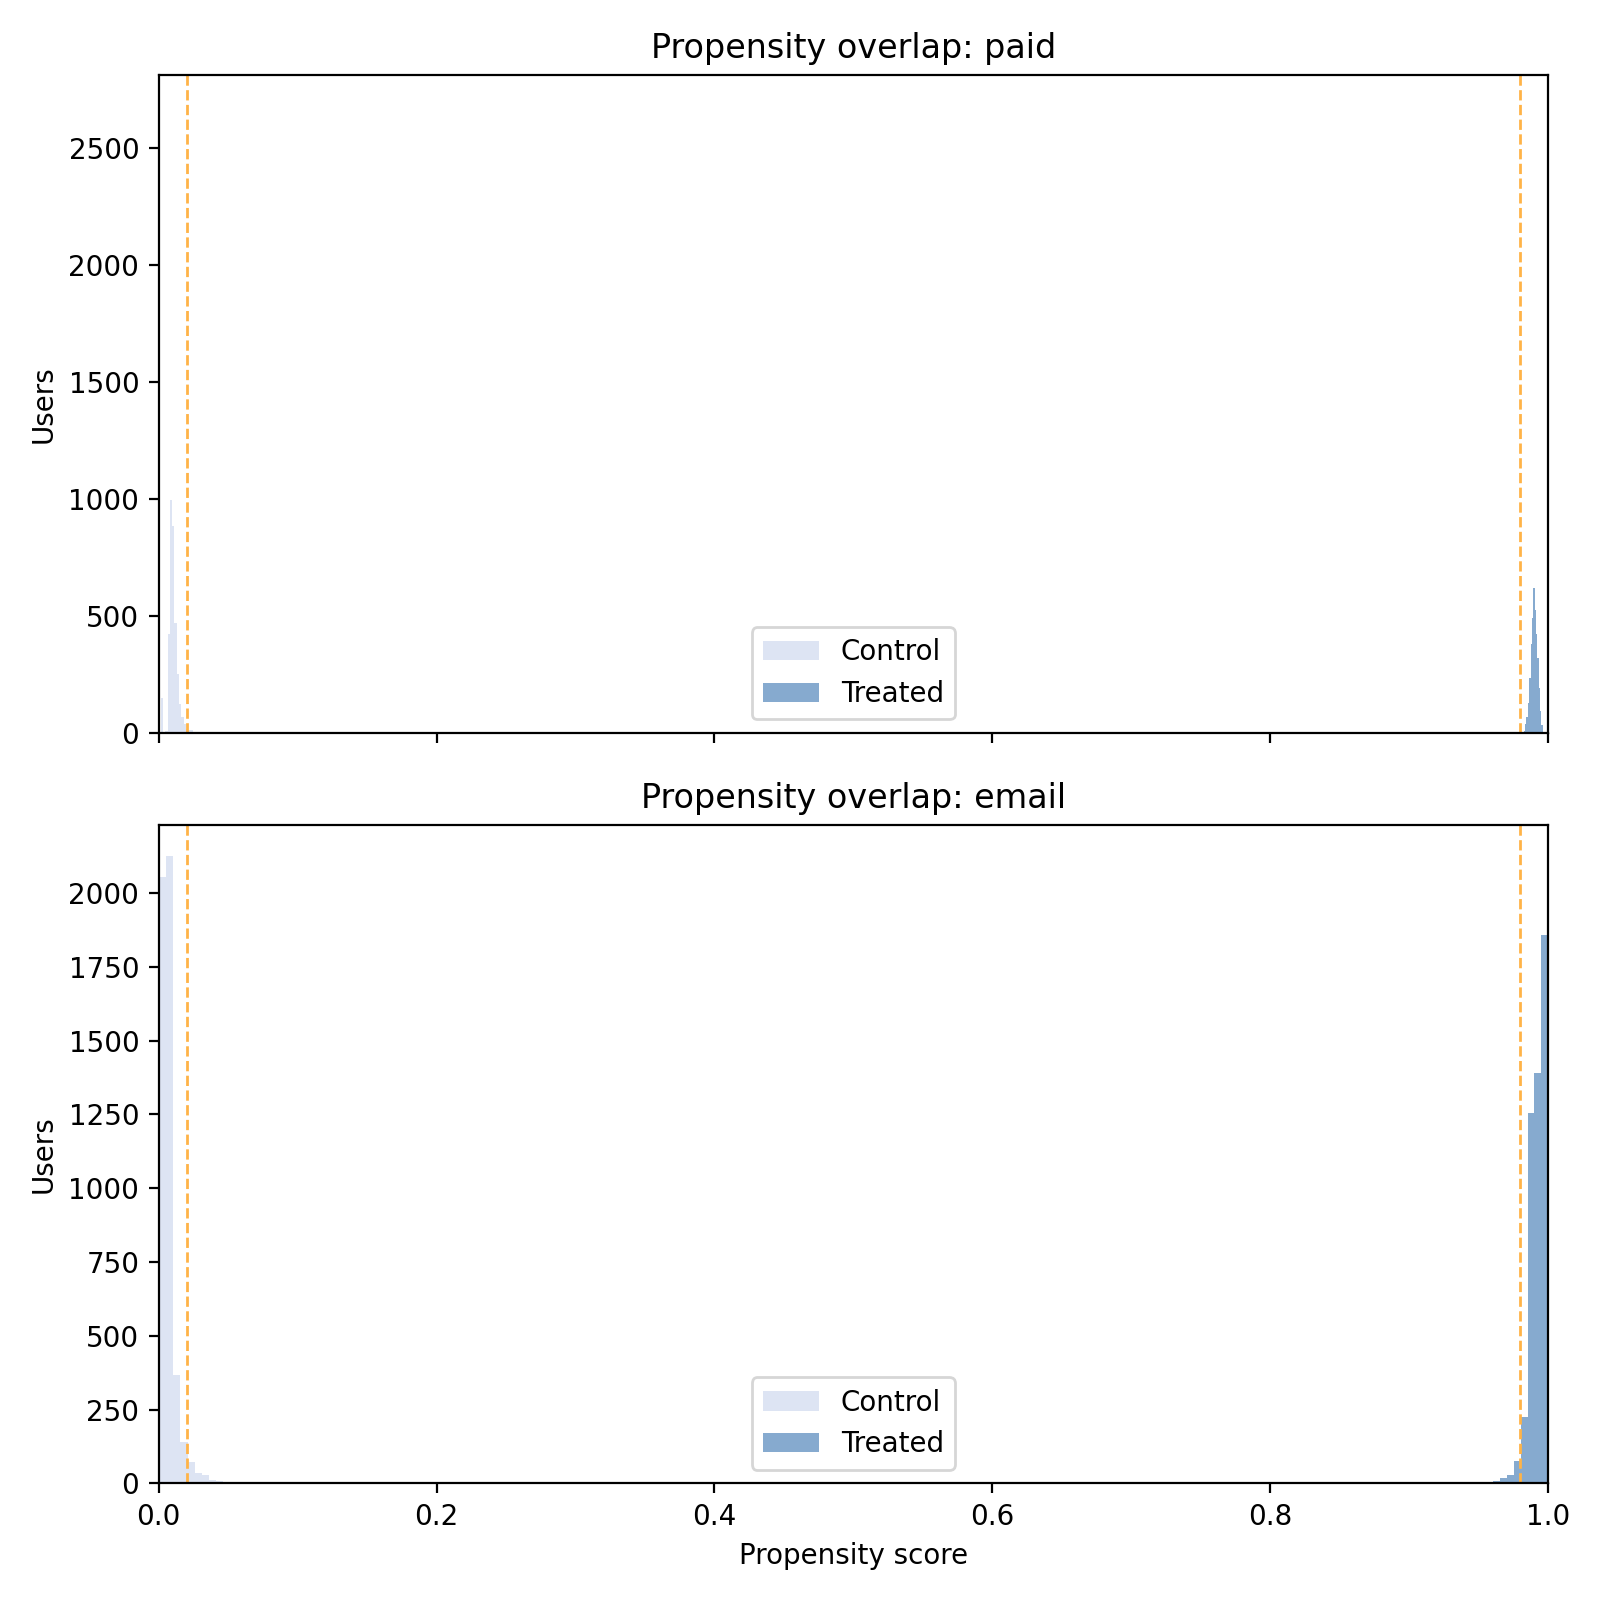

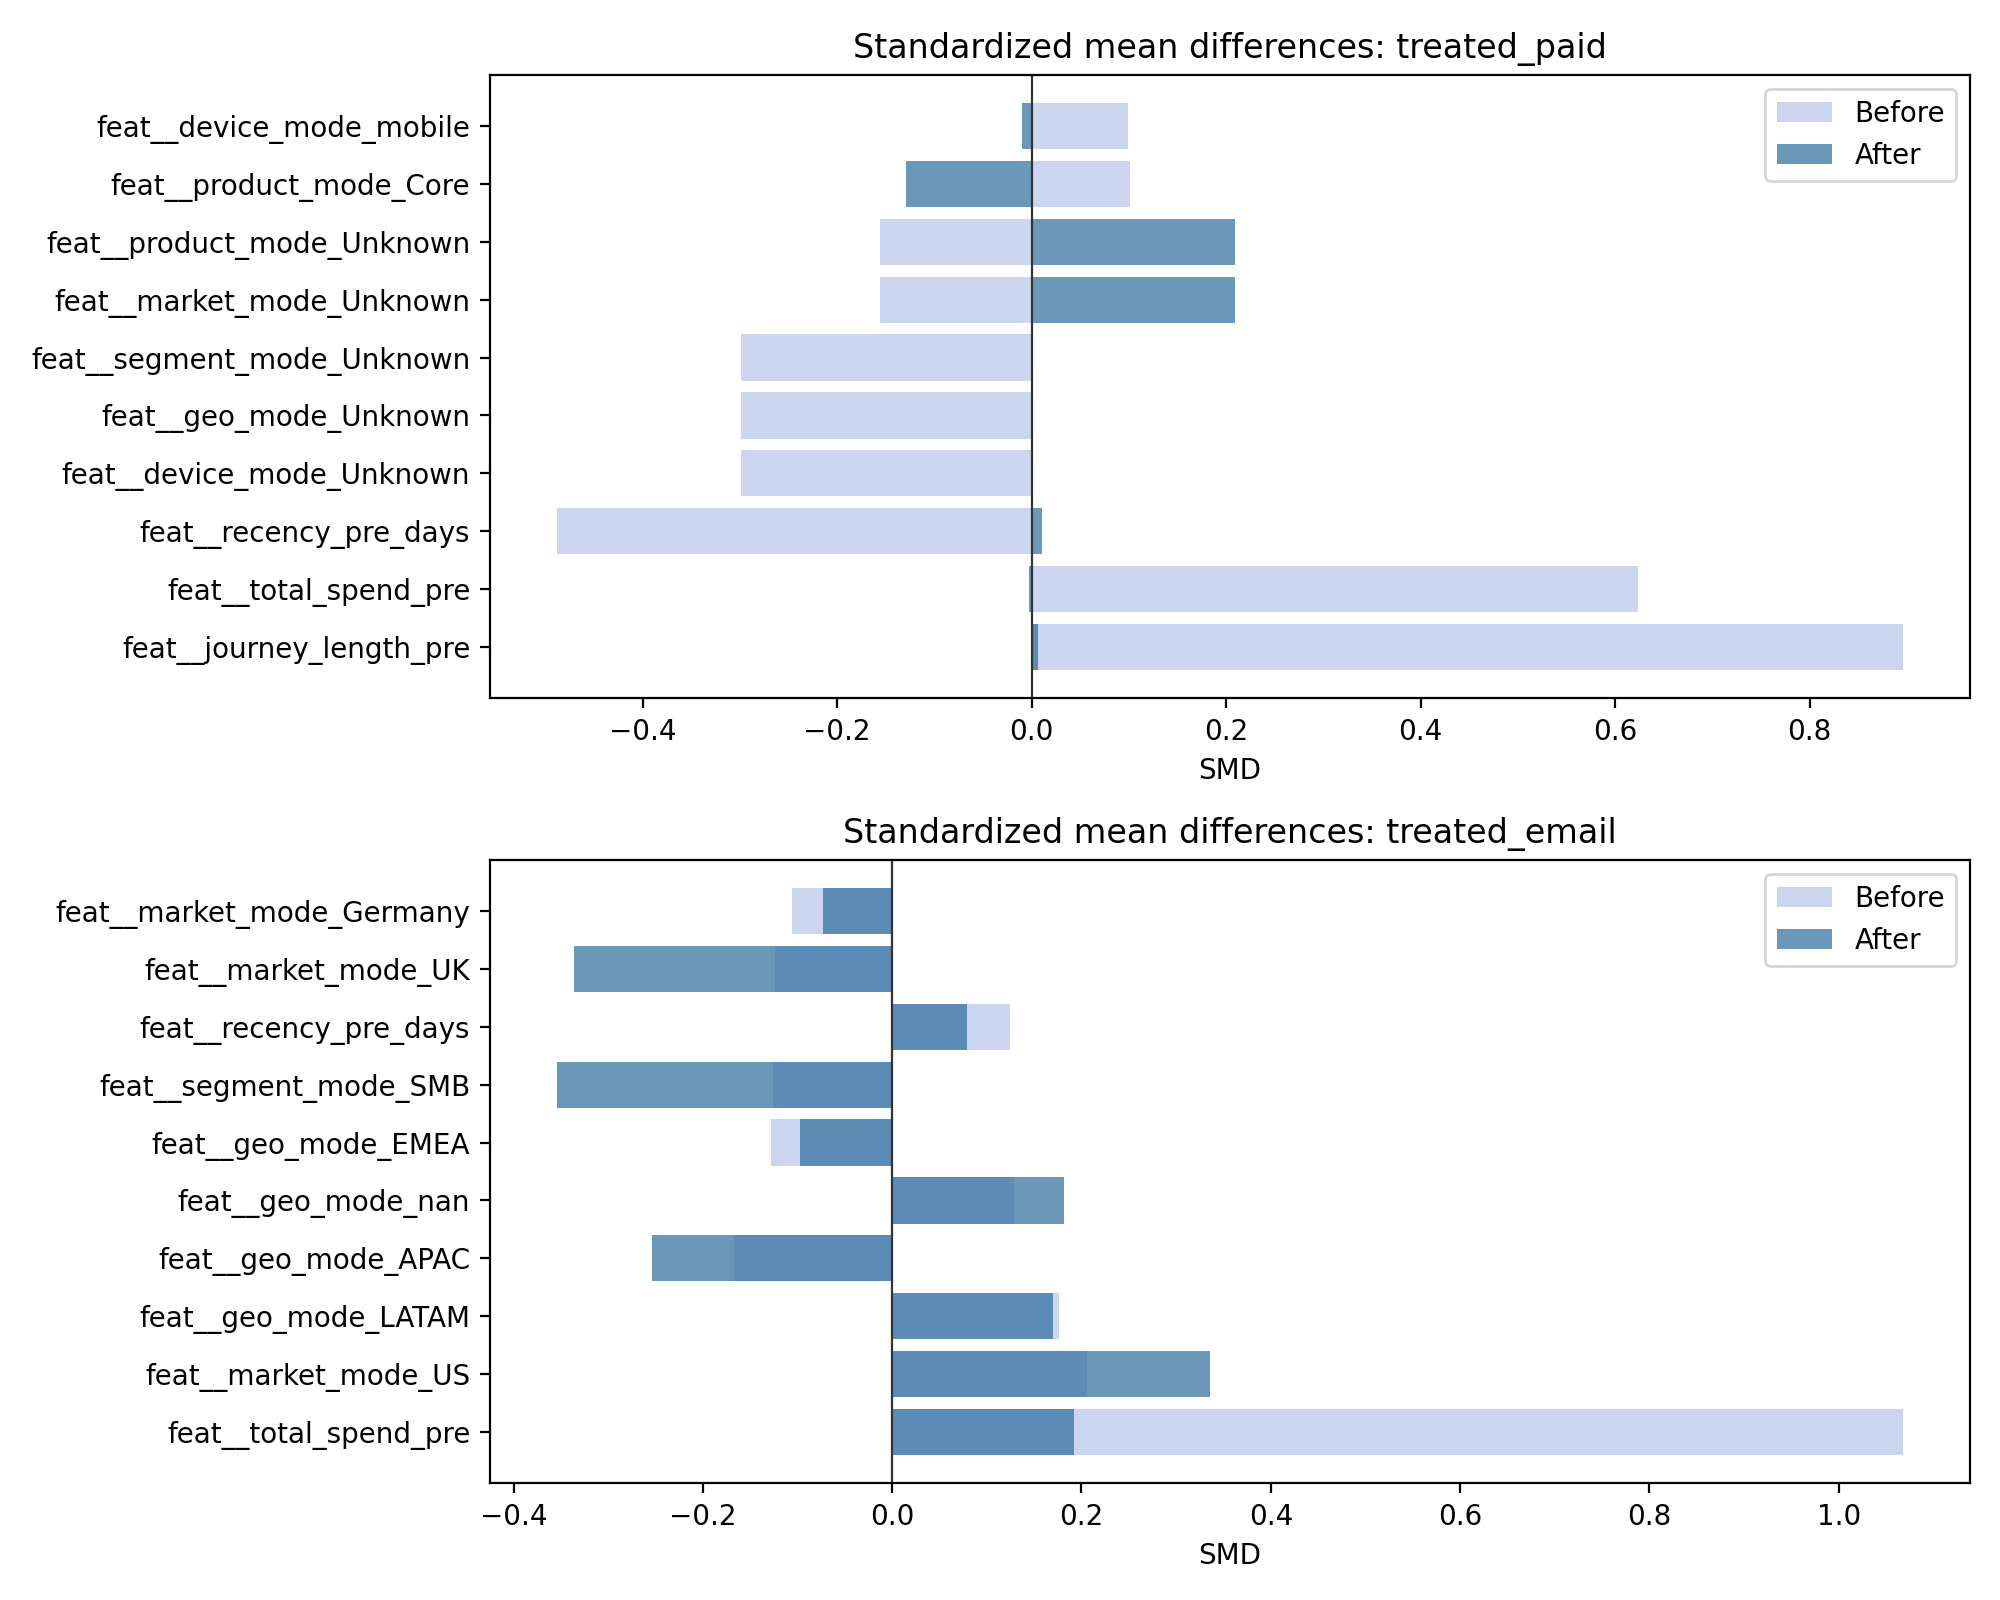

In [4]:
display(Image(filename=str(FIG_DIR / 'propensity_overlap.png')))
display(Image(filename=str(FIG_DIR / 'psm_balance_plot.png')))

## Decision highlights

In [5]:
paid_att = (
    psm_results
    .query("treatment == 'treated_paid' and outcome == 'y_conv'")
    ['estimate']
    .iat[0]
)
email_att = (
    psm_results
    .query("treatment == 'treated_email' and outcome == 'y_conv'")
    ['estimate']
    .iat[0]
)
paid_ipw_rev = (
    ipw_results
    .query("treatment == 'treated_paid' and method == 'IPW_ATE' and outcome == 'y_rev'")
    ['estimate']
    .iat[0]
)
email_aipw_rev = (
    ipw_results
    .query("treatment == 'treated_email' and method == 'AIPW' and outcome == 'y_rev'")
    ['estimate']
    .iat[0]
)
points = [
    f"- Paid ATT lift: {paid_att:.2%} conversion-rate bump among exposed journeys.",
    f"- Email ATT lift: {email_att:.2%} conversion-rate bump; nurture stays incremental.",
    f"- Paid IPW revenue lift: ${paid_ipw_rev:,.0f} per user; monitor negative or flat estimates.",
    f"- Email AIPW revenue lift: ${email_aipw_rev:,.0f} per user, reinforcing lifecycle triggers.",
    "- Prioritize tests where overlap/balance are strongest and budget can be shifted quickly.",
]
display(Markdown('\n'.join(points)))

- Paid ATT lift: 3.59% conversion-rate bump among exposed journeys.
- Email ATT lift: 6.45% conversion-rate bump; nurture stays incremental.
- Paid IPW revenue lift: $-9 per user; monitor negative or flat estimates.
- Email AIPW revenue lift: $18 per user, reinforcing lifecycle triggers.
- Prioritize tests where overlap/balance are strongest and budget can be shifted quickly.

## What to do next
- Spin up geo or audience-level holdout for paid to validate the negative incremental ROI.
- Double down on email retargeting creatives and experiment with incremental budget.
- Refresh propensity features quarterly to keep overlap healthy.
- Fold this notebook output into the exec dashboard after each pipeline run.